# UNIVERSIDAD INTERNACIONAL DE VALENCIA
## MIAR - ALGORITMOS DE OPTIMIZACIÓN

**Nombre:** Graciela Elizabeth Medina Toapanta

**GoogleColab:** https://drive.google.com/drive/folders/1RTAVTssCcB-UHXLEN4JlCDt6_2Hpm6yX?usp=drive_link

**Github:** https://github.com/gemedinat/MIAR_ALGORITMOS_DE_OPTIMIZACION.git

# Carga de librerias

In [1]:
 #Hacer llamadas http a paginas de la red
!pip install requests   

In [2]:
#Modulo para las instancias del problema del TSP
!pip install tsplib95    

# Carga de los datos del problema

In [3]:
import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios


#http://elib.zib.de/pub/mp-testdata/tsp/tsplib/
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/

#Descargamos el fichero de datos(Matriz de distancias)
file = "swiss42.tsp" ;
# urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/swiss42.tsp.gz", file + '.gz')
# !gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#URL alternativa
# file = "swiss42.tsp" ;
# urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)




In [4]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())



In [5]:
Aristas

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 17),
 (0, 18),
 (0, 19),
 (0, 20),
 (0, 21),
 (0, 22),
 (0, 23),
 (0, 24),
 (0, 25),
 (0, 26),
 (0, 27),
 (0, 28),
 (0, 29),
 (0, 30),
 (0, 31),
 (0, 32),
 (0, 33),
 (0, 34),
 (0, 35),
 (0, 36),
 (0, 37),
 (0, 38),
 (0, 39),
 (0, 40),
 (0, 41),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (1, 20),
 (1, 21),
 (1, 22),
 (1, 23),
 (1, 24),
 (1, 25),
 (1, 26),
 (1, 27),
 (1, 28),
 (1, 29),
 (1, 30),
 (1, 31),
 (1, 32),
 (1, 33),
 (1, 34),
 (1, 35),
 (1, 36),
 (1, 37),
 (1, 38),
 (1, 39),
 (1, 40),
 (1, 41),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (2, 15),
 (2, 16),
 (2, 17),
 (2, 18),


In [6]:
#Comprobar el nombre del problema
print(problem.name)

#Comprobar el número de Nodos
print(len(Nodos))

#Comprobar los 10 primeros Nodos
print(Nodos[:10])

#Comprobar las 10 primeras Aristas
print(Aristas[:10])

swiss42
42
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9)]



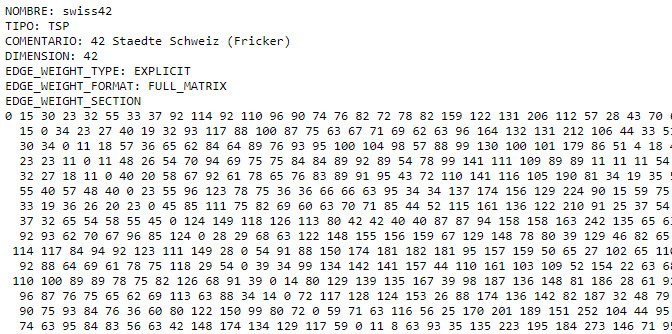

In [ ]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(0, 1)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

15

In [9]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo solucion TSP")
    plt.show()

# Funcionas basicas


In [10]:

#Funcionas basicas
###############################################################################

#Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

sol_temporal = crear_solucion(Nodos)

distancia_total(sol_temporal, problem), sol_temporal

(4209,
 [0,
  6,
  34,
  19,
  11,
  33,
  37,
  36,
  9,
  31,
  10,
  39,
  22,
  12,
  30,
  24,
  8,
  23,
  41,
  21,
  40,
  29,
  38,
  35,
  7,
  13,
  17,
  28,
  14,
  32,
  15,
  3,
  1,
  26,
  25,
  2,
  20,
  27,
  18,
  16,
  4,
  5])

# BUSQUEDA ALEATORIA

Mejor solución: [0, 4, 13, 28, 38, 35, 31, 17, 19, 39, 40, 24, 3, 27, 9, 8, 2, 6, 34, 23, 32, 18, 11, 26, 30, 36, 15, 16, 14, 25, 12, 5, 7, 29, 10, 41, 37, 20, 33, 22, 21, 1]
Distancia     : 3598


C:\Users\asus\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


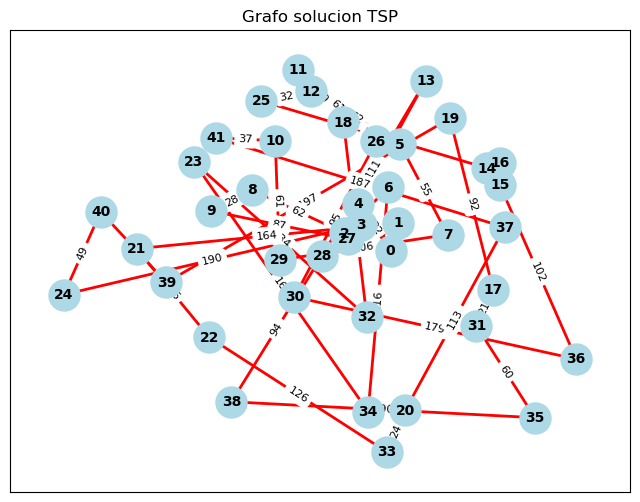

In [11]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  #mejor_distancia = 10e100                         #Inicializamos con un valor alto
  mejor_distancia = float('inf')                    #Inicializamos con un valor alto

  for i in range(N):                                #Criterio de parada: repetir N veces pero podemos incluir otros
    solucion = crear_solucion(Nodos)                #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)  #Calcula el valor objetivo(distancia total)

    if distancia < mejor_distancia:                 #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia


  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion


#Busqueda aleatoria con 10000 iteraciones
solucion = busqueda_aleatoria(problem, 10000)

plot_tsp_solution(problem.edge_weights, solucion)

#BUSQUEDA LOCAL

In [12]:
###############################################################################
# BUSQUEDA LOCAL
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  #Se puede modificar para aplicar otros generadores distintos que 2-opt
  #print(solucion)
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)-1):          #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))


nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3598
Distancia Mejor Solucion Local: 3383


En la iteracion  38 , la mejor solución encontrada es: [0, 18, 12, 25, 11, 13, 19, 16, 15, 14, 6, 4, 2, 30, 38, 22, 23, 41, 10, 8, 9, 29, 34, 33, 35, 36, 31, 17, 37, 7, 5, 26, 40, 24, 21, 39, 28, 27, 3, 1, 20, 32]
Distancia     : 1944


C:\Users\asus\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


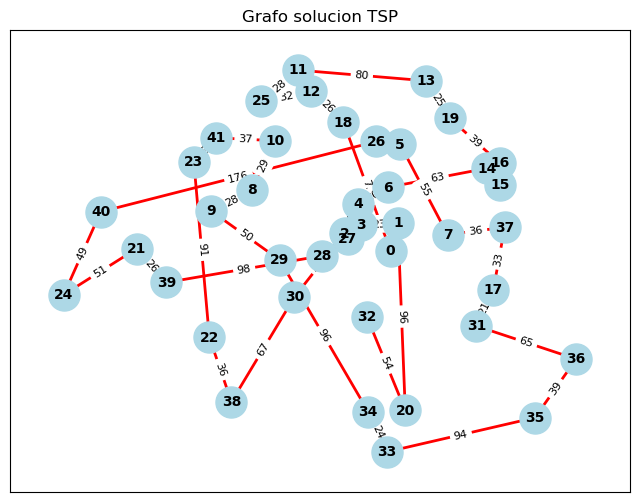

In [13]:
#Busqueda Local:
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.
def busqueda_local(problem):
  mejor_solucion = []

  #Generar una solucion inicial de referencia(aleatoria)
  solucion_referencia = crear_solucion(Nodos)
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador
    #print('#',iteracion)

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
      print("Distancia     :" , mejor_distancia)
      return mejor_solucion

    solucion_referencia = vecina


sol = busqueda_local(problem)

plot_tsp_solution(problem.edge_weights, sol)

#SIMULATED ANNEALING


In [14]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

#Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina.
def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


#Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T,d):
  if random.random() <  math.exp( -1*d / T)  :
    return True
  else:
    return False

#Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.99

La mejor solución encontrada es [0, 40, 24, 38, 31, 17, 14, 16, 15, 37, 36, 35, 33, 20, 22, 39, 21, 23, 9, 8, 10, 2, 28, 29, 30, 34, 32, 7, 13, 19, 5, 6, 26, 25, 41, 11, 12, 18, 4, 27, 3, 1]
con una distancia total de 2036


C:\Users\asus\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


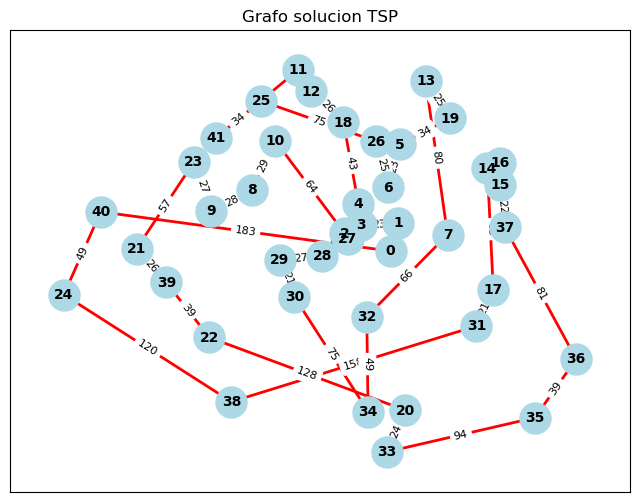

In [15]:
def recocido_simulado(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    vecina =genera_vecina_aleatorio(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado(problem, 10000000)

plot_tsp_solution(problem.edge_weights, sol)

# Actividades extra

**Mejora de algoritmo de búsqueda local**

*   Multiarranque
*   Busqueda en entornos variables

**Recocido simulado**

*   Mejora en la selección de vecinos



**1. Mejora en Búsqueda Local**

- Se vuelve a escribir la función de **busqueda_local** para que se pueda agregar una solución inicial como parámetro y devuelva la coordenada (solución, distancia).
- Se agrega **busqueda_local_multiarranque(problem, N_ARRANQUES)** que manda n búsquedas locales independientes y de esa manera se puede conservar el mejor resultado global.



Arranque  1: minimo local =   1698  |  mejor global =   1698
Arranque  2: minimo local =   1522  |  mejor global =   1522
Arranque  3: minimo local =   1859  |  mejor global =   1522
Arranque  4: minimo local =   1811  |  mejor global =   1522
Arranque  5: minimo local =   1792  |  mejor global =   1522
Arranque  6: minimo local =   1946  |  mejor global =   1522
Arranque  7: minimo local =   1744  |  mejor global =   1522
Arranque  8: minimo local =   1844  |  mejor global =   1522
Arranque  9: minimo local =   1593  |  mejor global =   1522
Arranque 10: minimo local =   1829  |  mejor global =   1522

Mejor solución (multiarranque): [0, 37, 15, 16, 14, 19, 13, 5, 26, 8, 21, 24, 40, 23, 41, 10, 25, 11, 12, 18, 6, 1, 7, 17, 31, 36, 35, 20, 33, 34, 38, 22, 39, 9, 29, 30, 32, 28, 27, 2, 4, 3]
Distancia                     : 1522


C:\Users\asus\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


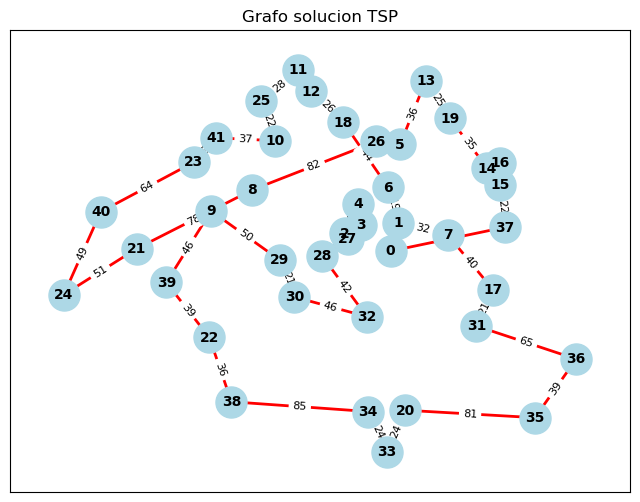

In [16]:
#Version parametrizada de la busqueda local:
#  - Admite una solucion inicial (si no se da, se genera una aleatoria)
#  - Devuelve (solucion, distancia) para poder reutilizarla en multiarranque y VNS
def busqueda_local_v2(problem, solucion_inicial=None, verbose=True):
  if solucion_inicial is None:
    solucion_referencia = crear_solucion(Nodos)   #Arranque aleatorio
  else:
    solucion_referencia = solucion_inicial        #Arranque dado

  mejor_solucion = solucion_referencia
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion = 0
  while True:
    iteracion += 1
    #Mejor vecina 2-opt de la solucion de referencia
    vecina = genera_vecina(solucion_referencia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si mejora seguimos; si no, hemos llegado a un minimo local y terminamos
    if distancia_vecina < mejor_distancia:
      mejor_solucion = vecina
      mejor_distancia = distancia_vecina
    else:
      if verbose:
        print("Minimo local alcanzado en la iteracion", iteracion, "con distancia", mejor_distancia)
      return mejor_solucion, mejor_distancia

    solucion_referencia = vecina


#Multiarranque: repetimos la busqueda local desde N soluciones iniciales aleatorias
#y nos quedamos con el mejor minimo local encontrado
def busqueda_local_multiarranque(problem, N_ARRANQUES=10):
  mejor_solucion_global = []
  mejor_distancia_global = float('inf')

  for arranque in range(N_ARRANQUES):
    solucion_inicial = crear_solucion(Nodos)                     #Nueva solucion inicial aleatoria
    solucion, dist = busqueda_local_v2(problem,
                                       solucion_inicial=solucion_inicial,
                                       verbose=False)            #Busqueda local completa

    if dist < mejor_distancia_global:                            #Actualizamos el mejor global
      mejor_solucion_global = solucion
      mejor_distancia_global = dist

    print(f"Arranque {arranque+1:2d}: minimo local = {dist:6.0f}  |  mejor global = {mejor_distancia_global:6.0f}")

  print("\nMejor solución (multiarranque):", mejor_solucion_global)
  print("Distancia                     :", mejor_distancia_global)
  return mejor_solucion_global


sol_multi = busqueda_local_multiarranque(problem, N_ARRANQUES=10)

plot_tsp_solution(problem.edge_weights, sol_multi)

**2. Búsqueda en entornos variables**

Utilizamos una técnica metaheurística VNS (Variable Neighborhood Search de Mladenović y Hansen, 1997). Esta técnica consiste en cambiar la estructura del entrono de forma sistemática para escapar de los mínimos locales y cuando la búsqueda local se bloquea se aplica un shaking cada vez más fuerte y se vuelve a lanzar la búsqueda local desde la solución que sufre la perturbación.

**Resumen del algoritmo (VNS básica):**
- Parámetro K = número de intercambios aleatorios
- Obtener un mínimo local con búsqueda local.
- Con K = 1: perturbar la solución actual con K intercambios aleatorios (*shaking* en el entorno k-ésimo).
- Aplicar búsqueda local a la solución perturbada.
- Si mejora, aceptar la nueva solución y volver a K= 1; si no, aumentar K (entorno más lejano) hasta K_MAX.
- Repetir hasta el criterio de parada (MAX_ITER ciclos completos).

> Se añaden `perturbar(solucion, k)` (aplica `k` intercambios aleatorios reutilizando la idea de `genera_vecina_aleatorio`) y `vns(problem, K_MAX, MAX_ITER)`, que reutiliza `busqueda_local_v2` como procedimiento de mejora.



Ciclo  1: mejor distancia =   1870
Ciclo  2: mejor distancia =   1870
Ciclo  3: mejor distancia =   1665
Ciclo  4: mejor distancia =   1665
Ciclo  5: mejor distancia =   1665
Ciclo  6: mejor distancia =   1665
Ciclo  7: mejor distancia =   1665
Ciclo  8: mejor distancia =   1665
Ciclo  9: mejor distancia =   1665
Ciclo 10: mejor distancia =   1665

Mejor solución (VNS): [0, 6, 26, 5, 7, 31, 20, 33, 34, 38, 22, 24, 21, 39, 30, 32, 35, 36, 17, 37, 15, 16, 14, 19, 13, 11, 25, 41, 23, 40, 9, 8, 10, 12, 18, 29, 28, 2, 27, 3, 4, 1]
Distancia           : 1665


C:\Users\asus\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


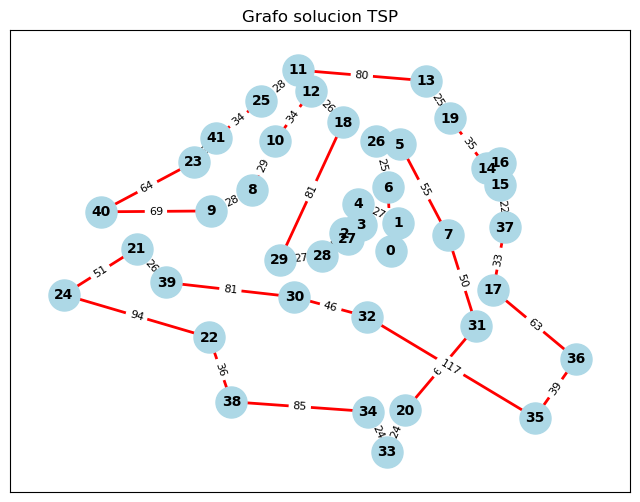

In [18]:
#Perturbacion ("shaking"): aplica k intercambios aleatorios de dos nodos.
#Cuanto mayor es k, mas lejos "saltamos" de la solucion actual (entorno mas amplio)
def perturbar(solucion, k):
  vecina = solucion[:]                                          #Copia de la solucion
  for _ in range(k):
    i, j = sorted(random.sample(range(1, len(vecina)), 2))      #Dos posiciones al azar (fijamos el nodo 0)
    vecina = vecina[:i] + [vecina[j]] + vecina[i+1:j] + [vecina[i]] + vecina[j+1:]
  return vecina


def vns(problem, K_MAX=5, MAX_ITER=10):
  #Solucion inicial: un minimo local obtenido por busqueda local
  solucion_actual, distancia_actual = busqueda_local_v2(problem, verbose=False)

  iteracion = 0
  while iteracion < MAX_ITER:                 #Criterio de parada
    iteracion += 1
    k = 1
    while k <= K_MAX:
      #1) Shaking: perturbamos la solucion actual en el entorno k
      candidata = perturbar(solucion_actual, k)

      #2) Busqueda local desde la solucion perturbada
      candidata, distancia_candidata = busqueda_local_v2(problem,
                                                         solucion_inicial=candidata,
                                                         verbose=False)

      #3) Si mejora: aceptamos y volvemos al primer entorno (k=1)
      #   Si no mejora: ampliamos el entorno (k+1)
      if distancia_candidata < distancia_actual:
        solucion_actual, distancia_actual = candidata, distancia_candidata
        k = 1
      else:
        k += 1

    print(f"Ciclo {iteracion:2d}: mejor distancia = {distancia_actual:6.0f}")

  print("\nMejor solución (VNS):", solucion_actual)
  print("Distancia           :", distancia_actual)
  return solucion_actual

sol_vns = vns(problem, K_MAX=5, MAX_ITER=10)

plot_tsp_solution(problem.edge_weights, sol_vns)

**3. Recocido Simulado**

Este algoritmo genera vecinos mediante el intercambio de nodos al azar (genera_vecina_aletorio), modificando hasta 4 aristas del recorrido produciendo un cambio fuerte en la distancia. Asimismo, sustituye el movimiento  **2-opt clásico por inversión de segmento** (Croes, 1958; Lin, 1965): se eligen dos posiciones i < j y se **invierte el orden del segmento** entre ambas. Esto permite eliminar exactamente 2 aristas y añadir otras dos generando que el paisaje de búsqueda sea más suave y que el recocido converga a soluciones mejores.

**Mejora:** se añade genera_vecina_inversion(solucion) y una versión recocido_simulado_mejorado idéntica al recocido original salvo por el generador de vecinas. Al final se comparan ambos operadores ejecutando varias veces cada versión.



La mejor solución encontrada es [0, 32, 34, 33, 20, 31, 35, 36, 17, 37, 16, 15, 14, 19, 13, 4, 6, 5, 26, 18, 12, 11, 25, 10, 41, 8, 23, 40, 24, 21, 9, 39, 22, 38, 28, 30, 29, 27, 2, 3, 7, 1]
con una distancia total de 1501


C:\Users\asus\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


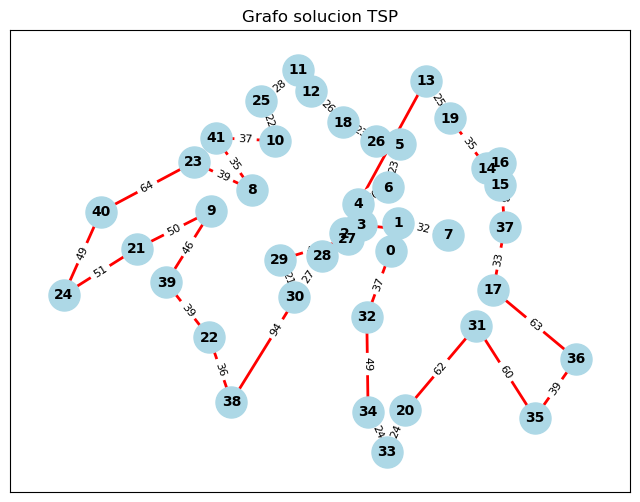

In [19]:
#Nuevo generador de vecinas: 2-opt por INVERSION de segmento.
#Se eligen dos posiciones i<j y se invierte el orden del segmento [i..j].
#Solo se sustituyen 2 aristas del ciclo (frente a hasta 4 del intercambio),
#lo que suaviza el paisaje de busqueda y elimina cruces del recorrido.
def genera_vecina_inversion(solucion):
  i, j = sorted(random.sample(range(1, len(solucion)), 2))
  return solucion[:i] + solucion[i:j+1][::-1] + solucion[j+1:]


def recocido_simulado_mejorado(problem, TEMPERATURA):
  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = solucion_referencia
  mejor_distancia = distancia_referencia

  while TEMPERATURA > .0001:
    #Unica diferencia con el recocido original: el generador de vecinas
    vecina = genera_vecina_inversion(solucion_referencia)
    distancia_vecina = distancia_total(vecina, problem)

    #Guardamos siempre la mejor solucion global encontrada
    if distancia_vecina < mejor_distancia:
      mejor_solucion = vecina
      mejor_distancia = distancia_vecina

    #Aceptacion: si mejora, siempre; si empeora, con probabilidad exp(-delta/T)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina)):
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es", mejor_solucion)
  print("con una distancia total de", mejor_distancia)
  return mejor_solucion


sol_sa_mejorado = recocido_simulado_mejorado(problem, 10000000)

plot_tsp_solution(problem.edge_weights, sol_sa_mejorado)

In [20]:
def sa_generico(problem, TEMPERATURA, generador):
  ref = crear_solucion(Nodos)
  d_ref = distancia_total(ref, problem)
  mejor = float('inf')
  while TEMPERATURA > .0001:
    v = generador(ref)
    dv = distancia_total(v, problem)
    if dv < mejor: mejor = dv
    if dv < d_ref or probabilidad(TEMPERATURA, abs(d_ref - dv)):
      ref, d_ref = v, dv
    TEMPERATURA = bajar_temperatura(TEMPERATURA)
  return mejor

REPES = 5
res_original = [sa_generico(problem, 10000000, genera_vecina_aleatorio) for _ in range(REPES)]
res_mejorado = [sa_generico(problem, 10000000, genera_vecina_inversion) for _ in range(REPES)]

print("SA original  (intercambio):", res_original, " -> media:", sum(res_original)/REPES)
print("SA mejorado  (inversion)  :", res_mejorado, " -> media:", sum(res_mejorado)/REPES)
print("\nOptimo conocido de swiss42: 1273")

SA original  (intercambio): [2079, 2174, 1816, 1993, 2033]  -> media: 2019.0
SA mejorado  (inversion)  : [1667, 1380, 1591, 1644, 1588]  -> media: 1574.0

Optimo conocido de swiss42: 1273


**Conclusión:**

> El algoritmo Multiarranque al lanzar la búsqueda local 2-opt desde varias soluciones iniciales aleatorias se obtienen distintos mínimos locales y se conserva el mejor, mejorando de forma sencilla el resultado de una sola ejecución (a costa de multiplicar el tiempo de cómputo por el número de arranques).

> En el VNS al combinar búsqueda local con perturbaciones de intensidad creciente (*shaking*), el algoritmo escapa de los mínimos locales y alcanza distancias mejores que el multiarranque puro con un esfuerzo similar, ya que cada relanzamiento parte de una solución ya buena en lugar de una totalmente aleatoria.

> El cambio del operador de vecindad (de intercambio de dos nodos a inversión de segmento 2-opt) es la mejora de mayor impacto: con los mismos parámetros de temperatura, la distancia media obtenida baja del entorno de ~2000 al entorno de ~1500, acercándose al óptimo conocido de swiss42 (1273). Esto confirma que en el TSP la elección del operador de vecindad condiciona la calidad del resultado tanto o más que el propio esquema metaheurístico.


## Referencias Bibliográficas

> Croes, G. A. (1958). *A method for solving traveling-salesman problems*. Operations Research, 6(6), 791–812.

> Kirkpatrick, S., Gelatt, C. D., & Vecchi, M. P. (1983). *Optimization by simulated annealing*. Science, 220(4598), 671–680.

> Lin, S. (1965). *Computer solutions of the traveling salesman problem*. Bell System Technical Journal, 44(10), 2245–2269.

> Martí, R. (2003). *Multi-start methods*. En F. Glover & G. A. Kochenberger (Eds.), Handbook of Metaheuristics (pp. 355–368). Kluwer Academic Publishers.

> Mladenović, N., & Hansen, P. (1997). *Variable neighborhood search*. Computers & Operations Research, 24(11), 1097–1100.

> Hansen, P., & Mladenović, N. (2001). *Variable neighborhood search: Principles and applications*. European Journal of Operational Research, 130(3), 449–467.

> Reinelt, G. (1991). *TSPLIB — A traveling salesman problem library*. ORSA Journal on Computing, 3(4), 376–384. Instancias disponibles en: http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/

> Talbi, E.-G. (2009). *Metaheuristics: From Design to Implementation*. John Wiley & Sons.

> Documentación de tsplib95: https://tsplib95.readthedocs.io/